In [1]:
import os 
os.chdir(r'C:\Users\HimanshuG\Desktop\ds_env\Scripts\Onece Again Data science course\My Notebook\Job simulation')

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HimanshuG\Desktop\ds_env\Scripts\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

df = pd.read_excel('QVI_transaction_data.xlsx')
print(df.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  


In [4]:
df.shape

(264836, 8)

In [5]:
print("Missing Value:\n" ,df.isnull().sum())

Missing Value:
 DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64


In [6]:
# DATE Field me proper date formate dalna of date.
# df['DATE'] = pd.to_datetime(df['DATE'] ,origin='1889-12-30',unit='D')
# Name: DATE, Length: 264836, dtype: datetime64[s]' is not compatible with origin='1889-12-30'; it must be numeric with a unit specified
# ye aaye to samjh jao ki Pahale se hi set hai date in proper format.
# to check it -
print("\n Date Column Head :\n",df['DATE'].head())


 Date Column Head :
 0    43390
1    43599
2    43605
3    43329
4    43330
Name: DATE, dtype: int64


## There are other products in our file other then chips like - 'Salsa'
### We have to remove other products because we have to Analysis only on chips.
1.Firstly check how many products is present in "Salsa"

In [7]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='str')

In [8]:
Salsa_count = df['PROD_NAME'].str.lower().str.contains('salsa').sum()
print("Total Salsa Products:",Salsa_count)

Total Salsa Products: 18094


In [9]:
# Removing the Salsa Products by saving those products which haven't salsa products in another variable.
df=df[~df['PROD_NAME'].str.lower().str.contains('salsa')]
print("Data Shape after removing Salsa Products:",df.shape)

Data Shape after removing Salsa Products: (246742, 8)


## Finding Outliers. - esa koi jisne kafi sare chips khareed liye ho.

In [10]:
# it provides the Count , mean , min , max , std and Q1,Q2,Q2 of Data.
print(df.describe()) 

                DATE      STORE_NBR  LYLTY_CARD_NBR        TXN_ID  \
count  246742.000000  246742.000000    2.467420e+05  2.467420e+05   
mean    43464.054875     135.051098    1.355310e+05  1.351311e+05   
std       105.396691      76.787096    8.071528e+04  7.814772e+04   
min     43282.000000       1.000000    1.000000e+03  1.000000e+00   
25%     43373.000000      70.000000    7.001500e+04  6.756925e+04   
50%     43464.000000     130.000000    1.303670e+05  1.351830e+05   
75%     43555.000000     203.000000    2.030840e+05  2.026538e+05   
max     43646.000000     272.000000    2.373711e+06  2.415841e+06   

            PROD_NBR       PROD_QTY      TOT_SALES  
count  246742.000000  246742.000000  246742.000000  
mean       56.351789       1.908062       7.321322  
std        33.695428       0.659831       3.077828  
min         1.000000       1.000000       1.700000  
25%        26.000000       2.000000       5.800000  
50%        53.000000       2.000000       7.400000  
75%    

## We got an Outlier in PROD_QTY it's in max with the value of 200.00.
### so now we have to look for this customer also what else he/she percheses with chips.

In [11]:
# Look for those transation jisme 200 packet buy kiye.
Outlier_transactions = df[df['PROD_QTY']==200]
print(Outlier_transactions)
# Now we have all fatial information of those Customer.

        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762  43331        226          226000  226201         4   
69763  43605        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [12]:
# Check all transaction of this customer.
# did we got other transaction.
Customer_transaction = df[df['LYLTY_CARD_NBR']==226000]
print(Customer_transaction)

        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762  43331        226          226000  226201         4   
69763  43605        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [13]:
# No , it's not a regular customer. Ye commercial Purpose ke liye hi buy kar raha hai.
# We have to remove this Customer kyuki hame sirf Retail customers ka Analysis karna hai.

In [14]:
# Customer - 226000 ko remove karna hai.
df=df[df['LYLTY_CARD_NBR']!=226000]
print("Data Shape after removing Outlier: ",df.shape)
# removed 2 entries from data.

Data Shape after removing Outlier:  (246740, 8)


## Missing Date - Kitne din shop Close rahi thi finding.
### To find this we'll check ki hamare date me kitni alag alag dates hai.

In [15]:
# Count ki har din kitne transactions huye.
transaction_by_date = df['DATE'].value_counts().sort_index()
print("Total unique dates: " , len(transaction_by_date))

Total unique dates:  364


In [16]:
# Total unique dates = 364 to 1 din ya to chips nhi sell huye ya shop close thi.
# lets find out that day.

In [17]:
# make a calender of those dates which we have in our data.
all_dates = pd.date_range(start = df['DATE'].min() , end = df['DATE'].max())
# Find missing date after matching it.
missing_date = all_dates.difference(df['DATE'].unique())
print("Missing Date is:\n",missing_date)

Missing Date is:
 DatetimeIndex(['1970-01-01 00:00:00.000043282'], dtype='datetime64[ns]', freq='D')


In [18]:
# 25 Dec 2008 that mean us din - Christmas Day tha to shop close thi.

In [19]:
# Two step varification - Hamara Data ab fully clean ho gaya ki nhi.

Verification 1 (Outliers Check) - Chips ki Quantity and Total sales normal hai na.
Verification 2 (Product Text Check) - Salsa Hatane ke baad koi or product to nhi bachi hai. to check this - we count the words of name of Products. 

In [20]:
print("--- 1. Statistics Check ---")
print(df[['PROD_QTY','TOT_SALES']].describe())
# There is no any outlier left.

--- 1. Statistics Check ---
            PROD_QTY      TOT_SALES
count  246740.000000  246740.000000
mean        1.906456       7.316113
std         0.342499       2.474897
min         1.000000       1.700000
25%         2.000000       5.800000
50%         2.000000       7.400000
75%         2.000000       8.800000
max         5.000000      29.500000


In [21]:
words = df['PROD_NAME'].str.replace(r'[^a-zA-Z\s]','',regex = True).str.lower().str.split(expand=True).stack()
print("\n--- 2. Top 10 Words in Product Names ---")
print(words.value_counts().head(10))


--- 2. Top 10 Words in Product Names ---
g           236260
chips        49770
kettle       41288
salt         27976
cheese       27890
smiths       27390
pringles     25102
crinkle      22490
corn         22061
doritos      22041
Name: count, dtype: int64


# Feature Engineering 
## For Strategy purpose - we should know the size of pack.
- make a new column ('PACK_SIZE')

In [22]:
df['PACK_SIZE']=df['PROD_NAME'].str.extract(r'(\d+)').astype(float)
# checking the weight of small and Large packet.
print("Pack Sizes Summery:\n",df['PACK_SIZE'].describe())
# So we have small and large size packet's weight - small = 70g and Large = 380g.

Pack Sizes Summery:
 count    246740.000000
mean        175.583521
std          59.432118
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64


In [23]:
# Making a new column named = BRAND. to know the name of brand of Chips.

In [24]:
df['BRAND']=df['PROD_NAME'].str.split().str[0]
print("Brands Summary:\n",df['BRAND'].value_counts())

Brands Summary:
 BRAND
Kettle        41288
Smiths        27390
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64


In [25]:
# There's correction in name of Brand . lets correct it.
brand_corrections={
    'RED':'RRD',
    'Red':'RRD',
    'Dorito':'Doritos',
    'Infzns':'Infuzions',
    'WW':'Woolworths',
    'Smith':'Smiths',
    'Snbts':'Sunbites',
    'Grain':'GrnWves', # Grain Waves
    'NCC':'Natural'# Natural Chip Co
}
df['BRAND']= df['BRAND'].replace(brand_corrections)
print("Clean Brand Summary:\n",df['BRAND'].value_counts())

Clean Brand Summary:
 BRAND
Kettle        41288
Smiths        30353
Doritos       25224
Pringles      25102
RRD           16321
Infuzions     14201
Thins         14075
Woolworths    11836
Cobs           9693
Tostitos       9471
Twisties       9454
GrnWves        7740
Natural        7469
Tyrrells       6442
Cheezels       4603
CCs            4551
Sunbites       3008
Cheetos        2927
Burger         1564
French         1418
Name: count, dtype: int64


In [26]:
# MERGER of both Transaction Data and  Customer Data through LYLTY_CARD_NBR.

In [27]:
customer_data = pd.read_csv('QVI_purchase_behaviour.csv')

In [28]:
merged_data = pd.merge(df,customer_data,on="LYLTY_CARD_NBR",how='left')
# checking if there any duplicated row to create nhi ho gayi.
print("Rows in df: ", len(df))
print("Rows in merged data: ",len(merged_data))
# checking if there any customer jiski details match nhi huyi.
print("\n missing value after merge:\n",merged_data.isnull().sum())

Rows in df:  246740
Rows in merged data:  246740

 missing value after merge:
 DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


# So Finally we have 100% cleaned data.
#     Lets make Charts and Graphs after save this file.

In [29]:
merged_data.to_csv('QVI_data.csv',index=False)
print("Data Successfully saved as 'QVI_data.csv'! ")

Data Successfully saved as 'QVI_data.csv'! 


# EDA

In [30]:
import pandas as pd

In [31]:
merged_data = pd.read_csv('QVI_data.csv')

Q1 - Total Sales: Which customer segment generated the highest revenue?

Q2 - Customer Count: Does this segment also have the maximum customer volume?

Q3 - Average Price: Which segment purchases the highest-priced chips?

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Set Design of chat
plt.style.use('ggplot')

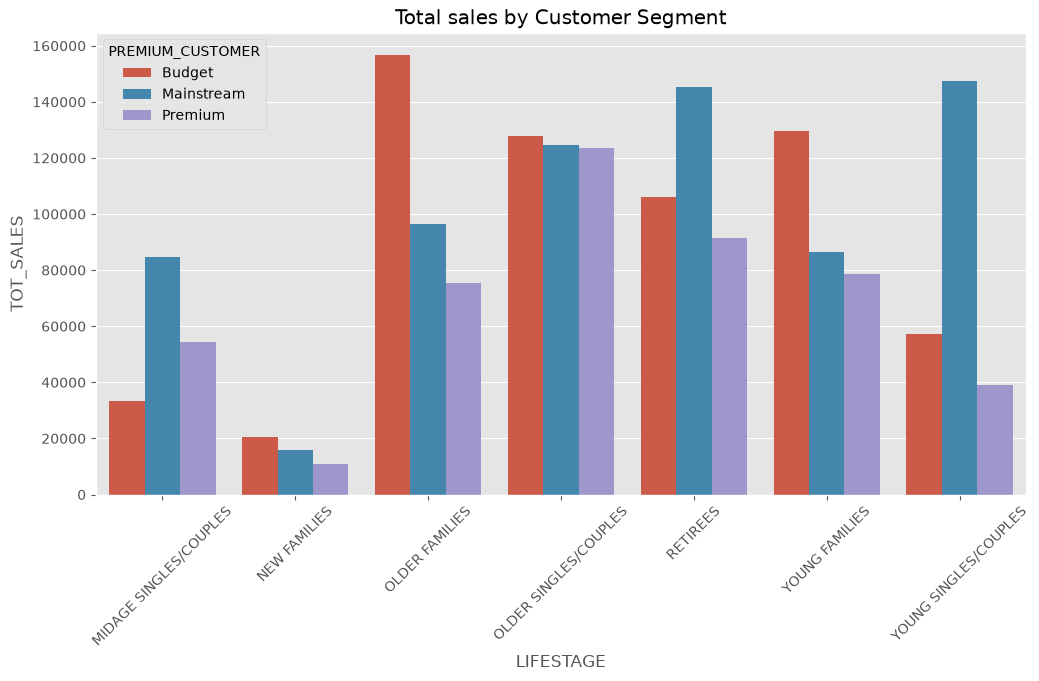

In [35]:
# Insight 1: Total sales
sales_summary = merged_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=sales_summary,x='LIFESTAGE',y='TOT_SALES',hue='PREMIUM_CUSTOMER')
plt.title('Total sales by Customer Segment')
plt.xticks(rotation=45)
plt.show()

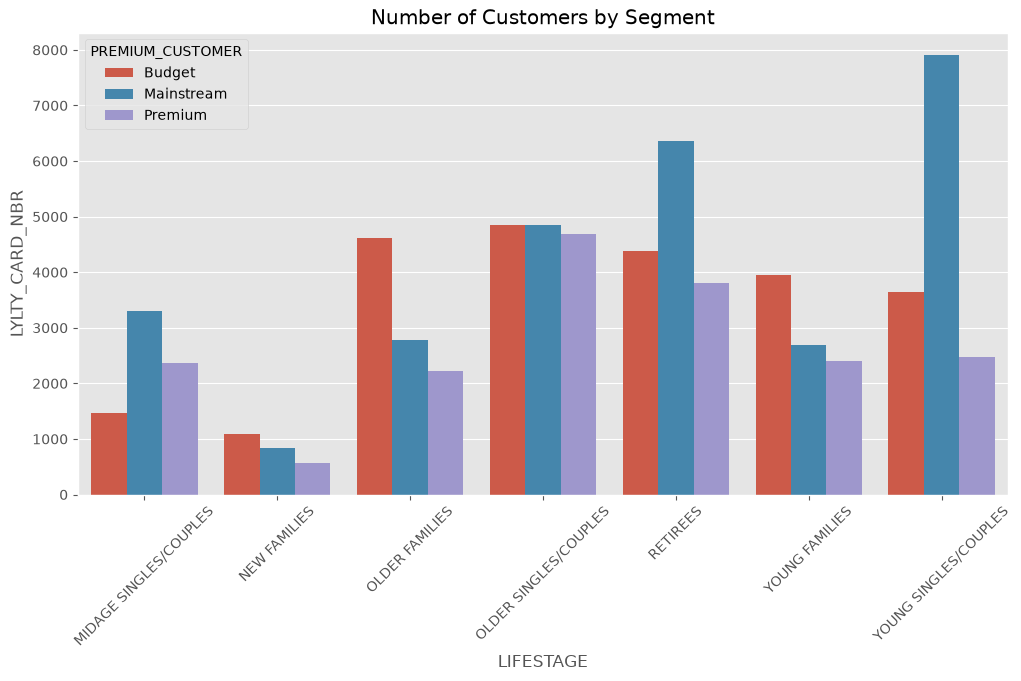

In [36]:
# Insight 2: Number of Customers
Customer_summery = merged_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=Customer_summery, x = 'LIFESTAGE',y='LYLTY_CARD_NBR',hue='PREMIUM_CUSTOMER')
plt.title("Number of Customers by Segment")
plt.xticks(rotation = 45)
plt.show()

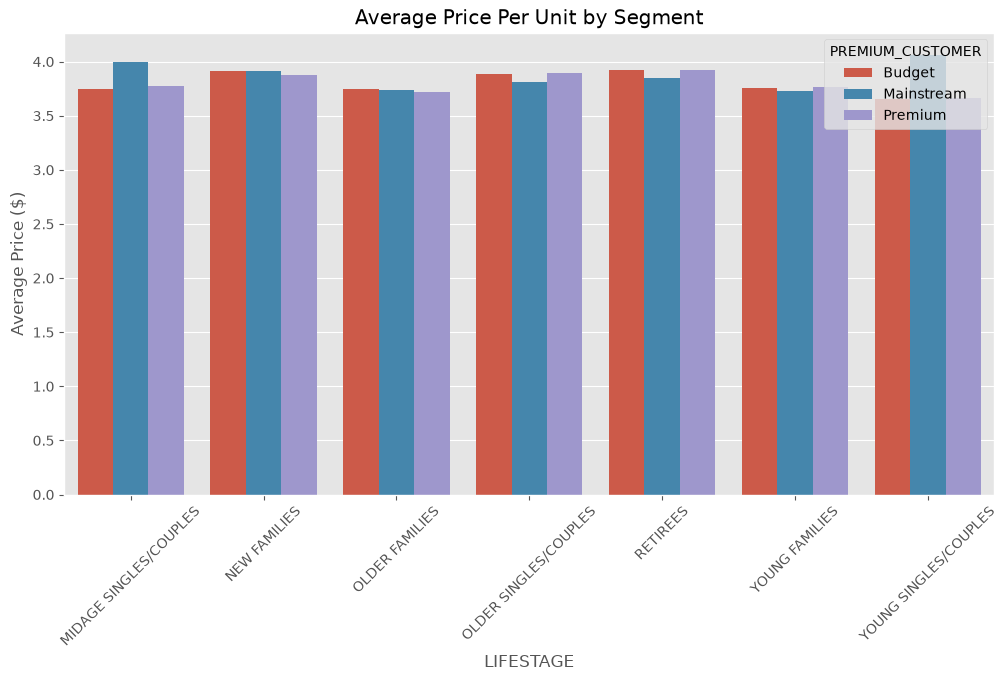

In [37]:
# Insight 3: Average Price
merged_data['PRICE_PER_UNIT']=merged_data['TOT_SALES']/merged_data['PROD_QTY']
avg_price = merged_data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PRICE_PER_UNIT'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=avg_price,x='LIFESTAGE',y='PRICE_PER_UNIT',hue="PREMIUM_CUSTOMER")
plt.title('Average Price Per Unit by Segment')
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')
plt.show()

In [39]:
# Target Segment ke Favorite BRAND and PACKET SIZE.

# 1. Differenciate target customer - (Young Singles/Couples - Mainstream)
target_segment=merged_data[(merged_data['LIFESTAGE']=="YOUNG SINGLES/COUPLES")&(merged_data['PREMIUM_CUSTOMER']=='Mainstream')]

# 2. Their Favorite BRAND.(top 5)
print("Top Brands for Target Segment")
print(target_segment['BRAND'].value_counts(normalize=True).head())

# 3. Their Favorite Packet size.(top 5)
print("\n Top Pack Sizes for Target Segment")
print(target_segment['PACK_SIZE'].value_counts(normalize=True).head())

Top Brands for Target Segment
BRAND
Kettle       0.196684
Doritos      0.121725
Pringles     0.118451
Smiths       0.098291
Infuzions    0.063958
Name: proportion, dtype: float64

 Top Pack Sizes for Target Segment
PACK_SIZE
175.0    0.255679
150.0    0.157593
134.0    0.118451
110.0    0.104943
170.0    0.080587
Name: proportion, dtype: float64


In [41]:
# Affinity Analysis
# lets differenciate Other Customer's data.

other_customers = merged_data[~((merged_data['LIFESTAGE']=='YOUNG SINGLE/COUPLES') & (merged_data['PREMIUM_CUSTOMER']=="Mainstream"))]
# target % / others %   = Affinity
target_brand = target_segment['BRAND'].value_counts(normalize=True)
other_brand = other_customers['BRAND'].value_counts(normalize=True)

affinity = target_brand / other_brand

print("Brand Affinity Index")
print(affinity.sort_values(ascending=False).head())

Brand Affinity Index
BRAND
Tyrrells    1.213098
Twisties    1.201858
Doritos     1.190712
Tostitos    1.186370
Kettle      1.175400
Name: proportion, dtype: float64


In [42]:
# My Final verdict.

# Kettle - The Most selling Brand.
# Tyrrells - Most Affinity.
# Favorite Pack size = 175g